In [12]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

INPUT_FILE = "survey_data.xlsx"
SHEET_NAME = "Data"
OUTPUT_XLSX = "customers_clustered.xlsx"


df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
df.head()


,CID,Q109_1,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
0,1,Sample,3.0,3.0,2.0,2.0,2.0,2.0,3.0,2.0,...,4.0,5.0,4.0,4.0,5.0,5.0,5.0,4.0,4.0,5.0
1,2,Sample,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3,non-sample,1.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,...,4.0,5.0,5.0,1.0,5.0,4.0,1.0,1.0,5.0,4.0
3,4,Sample,2.0,2.0,1.0,2.0,4.0,3.0,4.0,3.0,...,4.0,3.0,4.0,2.0,5.0,4.0,2.0,4.0,5.0,4.0
4,5,Sample,4.0,2.0,2.0,1.0,1.0,3.0,2.0,2.0,...,3.0,3.0,3.0,3.0,3.0,5.0,5.0,5.0,5.0,5.0


In [5]:
df.shape

(1316, 25)

In [6]:

df_cust = df[df["Q109_1"] == 'non-sample']

In [7]:
df_cust.head()

,CID,Q109_1,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
2,3,non-sample,1.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,...,4.0,5.0,5.0,1.0,5.0,4.0,1.0,1.0,5.0,4.0
124,125,non-sample,2.0,3.0,1.0,2.0,3.0,4.0,2.0,2.0,...,4.0,1.0,4.0,3.0,4.0,4.0,4.0,4.0,1.0,3.0
158,159,non-sample,3.0,4.0,1.0,1.0,1.0,2.0,3.0,2.0,...,4.0,4.0,5.0,3.0,4.0,3.0,2.0,3.0,2.0,4.0
159,160,non-sample,3.0,4.0,1.0,1.0,1.0,4.0,2.0,2.0,...,5.0,2.0,5.0,1.0,4.0,5.0,2.0,4.0,3.0,3.0
160,161,non-sample,2.0,3.0,1.0,1.0,2.0,2.0,2.0,1.0,...,3.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,3.0,4.0


In [8]:
df_cust = df[df["Q109_1"] == 'non-sample']

In [9]:

df_cust.shape

(513, 25)

In [13]:
excluir_cols = ["CID", "Q109_1"]

X_cust = df_cust.drop(excluir_cols, axis=1)
X_cust.head()


,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,Q1_10,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
2,1.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,4.0,4.0,...,4.0,5.0,5.0,1.0,5.0,4.0,1.0,1.0,5.0,4.0
124,2.0,3.0,1.0,2.0,3.0,4.0,2.0,2.0,2.0,4.0,...,4.0,1.0,4.0,3.0,4.0,4.0,4.0,4.0,1.0,3.0
158,3.0,4.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,...,4.0,4.0,5.0,3.0,4.0,3.0,2.0,3.0,2.0,4.0
159,3.0,4.0,1.0,1.0,1.0,4.0,2.0,2.0,3.0,2.0,...,5.0,2.0,5.0,1.0,4.0,5.0,2.0,4.0,3.0,3.0
160,2.0,3.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,4.0,...,3.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,3.0,4.0


Defino un pipeline para escalar los datos y clusterizar con k=3. Uso el algoritmo k-means y la distancia euclídea (está configurada por defecto)

In [14]:

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=10))
])

In [15]:
clusters = pipe.fit_predict(X_cust)
df_cust["cluster"] = clusters

In [16]:
df_cust.head()


,CID,Q109_1,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,...,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12,cluster
2,3,non-sample,1.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,...,5.0,5.0,1.0,5.0,4.0,1.0,1.0,5.0,4.0,1
124,125,non-sample,2.0,3.0,1.0,2.0,3.0,4.0,2.0,2.0,...,1.0,4.0,3.0,4.0,4.0,4.0,4.0,1.0,3.0,0
158,159,non-sample,3.0,4.0,1.0,1.0,1.0,2.0,3.0,2.0,...,4.0,5.0,3.0,4.0,3.0,2.0,3.0,2.0,4.0,1
159,160,non-sample,3.0,4.0,1.0,1.0,1.0,4.0,2.0,2.0,...,2.0,5.0,1.0,4.0,5.0,2.0,4.0,3.0,3.0,1
160,161,non-sample,2.0,3.0,1.0,1.0,2.0,2.0,2.0,1.0,...,3.0,4.0,2.0,4.0,4.0,4.0,1.0,3.0,4.0,2


In [17]:
q_cols = [col for col in df_cust.columns if col.startswith('Q1_') or col.startswith('Q2_')]
df_clustered_means = df_cust.groupby('cluster')[q_cols].mean()
df_clustered_means.head()

,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,Q1_10,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.532544,3.467456,1.822485,2.680473,2.798817,2.751479,2.195266,2.349112,2.414201,2.881657,...,3.562130,2.325444,3.710059,2.840237,2.544379,2.964497,2.698225,2.757396,2.414201,2.686391
1,2.855072,3.594203,1.429952,2.231884,1.995169,3.285024,2.642512,2.565217,2.618357,3.579710,...,4.077295,3.792271,4.695652,3.144928,3.922705,3.966184,3.444444,3.299517,2.541063,4.014493
2,1.912409,2.854015,1.299270,2.386861,1.897810,1.781022,1.810219,2.102190,1.744526,2.781022,...,4.240876,3.401460,4.532847,3.459854,3.598540,4.138686,3.919708,3.729927,2.408759,3.605839


In [18]:
df_clustered_means.round(1)

,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,Q1_10,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.5,3.5,1.8,2.7,2.8,2.8,2.2,2.3,2.4,2.9,...,3.6,2.3,3.7,2.8,2.5,3.0,2.7,2.8,2.4,2.7
1,2.9,3.6,1.4,2.2,2.0,3.3,2.6,2.6,2.6,3.6,...,4.1,3.8,4.7,3.1,3.9,4.0,3.4,3.3,2.5,4.0
2,1.9,2.9,1.3,2.4,1.9,1.8,1.8,2.1,1.7,2.8,...,4.2,3.4,4.5,3.5,3.6,4.1,3.9,3.7,2.4,3.6


In [ ]:
df_clustered_means.round(1).T

cluster,0,1,2
Q1_1,2.5,2.9,1.9
Q1_2,3.5,3.6,2.9
Q1_3,1.8,1.4,1.3
Q1_4,2.7,2.2,2.4
Q1_5,2.8,2.0,1.9
Q1_6,2.8,3.3,1.8
Q1_7,2.2,2.6,1.8
Q1_8,2.3,2.6,2.1
Q1_9,2.4,2.6,1.7
Q1_10,2.9,3.6,2.8


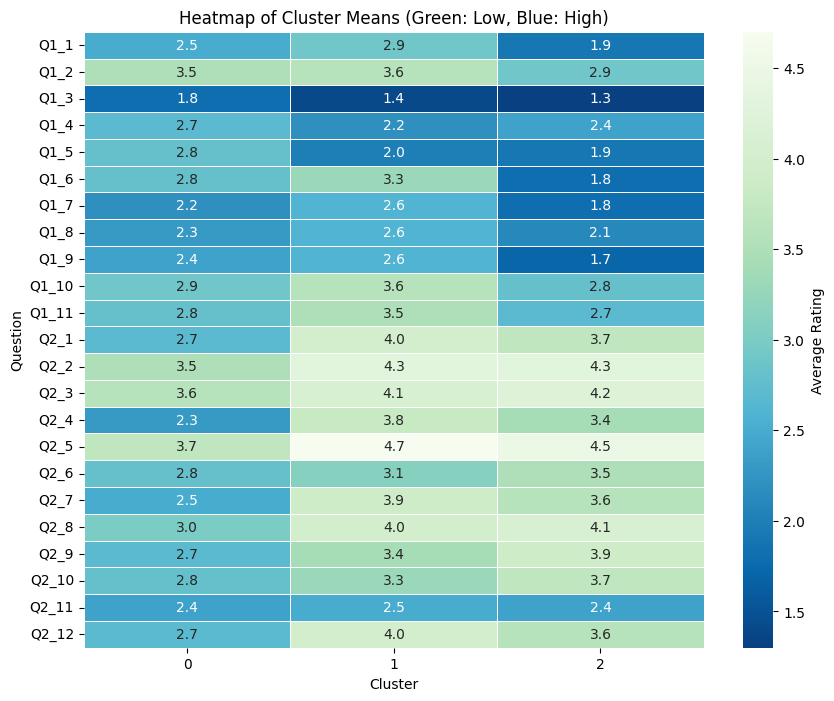

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df_clustered_means.round(1).T,
            cmap='GnBu_r', # Green for low values, Blue for high values (reversed Green-Blue colormap)
            annot=True,
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'Average Rating'})
plt.title('Heatmap of Cluster Means (Green: Low, Blue: High)')
plt.xlabel('Cluster')
plt.ylabel('Question')
plt.show()

In [19]:
translation_table = {
    'Q1_1': 'Price',
    'Q1_2': 'Research',
    'Q1_3': 'Motivation',
    'Q1_4': 'Nutrition',
    'Q1_5': 'Performance',
    'Q1_6': 'Social',
    'Q1_7': 'Exploration',
    'Q1_8': 'Priority',
    'Q1_9': 'Quality',
    'Q1_10': 'Time',
    'Q1_11': 'Activity',
    'Q2_1': 'Recovery',
    'Q2_2': 'Knowledge',
    'Q2_3': 'Maintenance',
    'Q2_4': 'Training',
    'Q2_5': 'Tracking',
    'Q2_6': 'Friends',
    'Q2_7': 'Goals',
    'Q2_8': 'Reading',
    'Q2_9': 'TV',
    'Q2_10': 'Events',
    'Q2_11': 'Indoors',
    'Q2_12': 'Competitive'
}

df_final_means = df_clustered_means.round(1).T
df_final_means['Question'] = df_final_means.index.map(translation_table)
df_final_means = df_final_means[['Question', 0, 1, 2]] # Reorder columns to have 'Question' first

df_final_means

cluster,Question,0,1,2
Q1_1,Price,2.5,2.9,1.9
Q1_2,Research,3.5,3.6,2.9
Q1_3,Motivation,1.8,1.4,1.3
Q1_4,Nutrition,2.7,2.2,2.4
Q1_5,Performance,2.8,2.0,1.9
Q1_6,Social,2.8,3.3,1.8
Q1_7,Exploration,2.2,2.6,1.8
Q1_8,Priority,2.3,2.6,2.1
Q1_9,Quality,2.4,2.6,1.7
Q1_10,Time,2.9,3.6,2.8


# Task
Generate a heatmap to visualize the mean ratings for each question across the clusters. First, prepare the data by combining the question code with its descriptive name (e.g., 'Q1_1 - Price') to form a new index. Then, create a heatmap using this prepared data, employing a custom diverging color scheme where white represents mid-range values, blue represents lower values, and green represents higher values.

## create_heatmap_data

### Subtask:
Prepare the data for the heatmap by creating a new index that combines the question code and its descriptive name. This will ensure each row in the heatmap has a clear label combining both pieces of information.


**Reasoning**:
To prepare the data for the heatmap, I will create a new combined index by concatenating the existing index (question code) with the 'Question' column (descriptive name) and then set this new column as the DataFrame's index. Finally, I will drop the original 'Question' column.



In [ ]:
df_final_means['Question_Code_Name'] = df_final_means.index + ' - ' + df_final_means['Question']
df_final_means = df_final_means.set_index('Question_Code_Name')
df_final_means = df_final_means.drop('Question', axis=1)
df_final_means.head()

cluster,0,1,2
Question_Code_Name,,,
Q1_1 - Price,2.5,2.9,1.9
Q1_2 - Research,3.5,3.6,2.9
Q1_3 - Motivation,1.8,1.4,1.3
Q1_4 - Nutrition,2.7,2.2,2.4
Q1_5 - Performance,2.8,2.0,1.9


**Reasoning**:
Now that the data is prepared with the combined question code and descriptive name as the index, I will generate the heatmap to visualize the mean ratings across clusters, using a custom diverging color scheme (blue for low, white for mid, green for high) as requested in the main task.



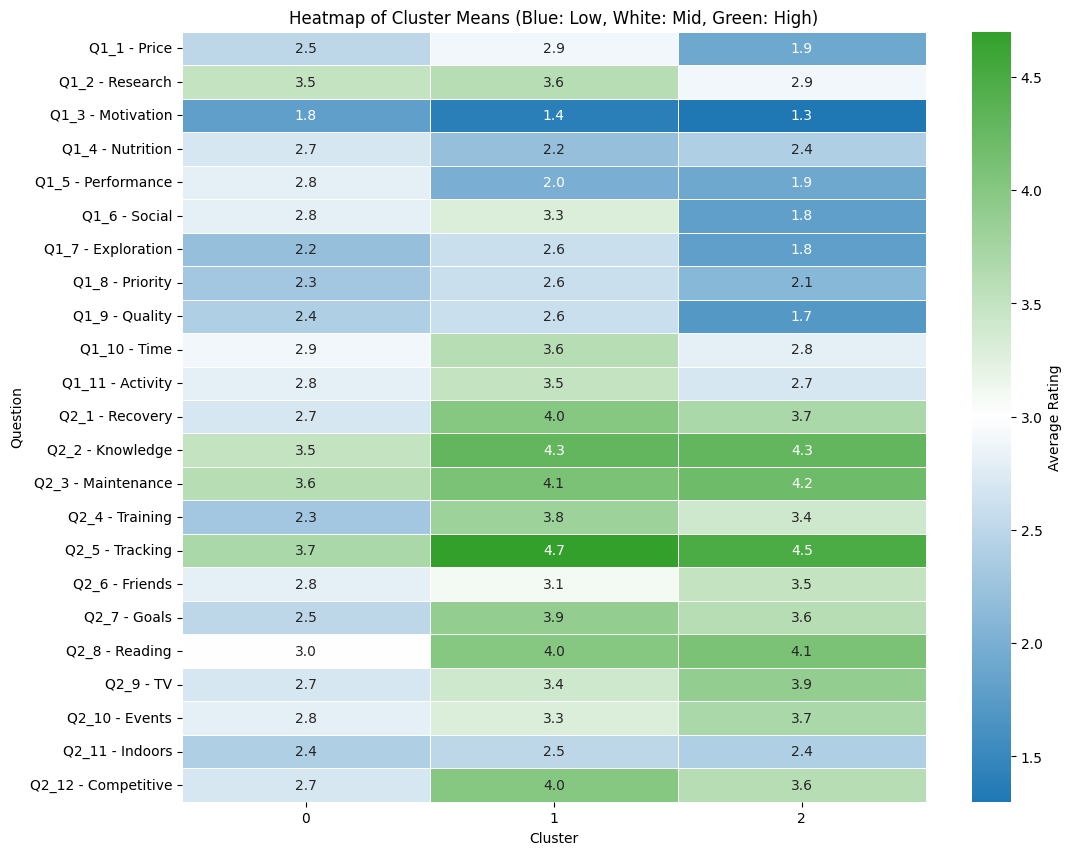

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# Define the custom diverging colormap: Blue (low) -> White (mid) -> Green (high)
cmap_colors = ["#1f78b4", "white", "#33a02c"]
custom_cmap = LinearSegmentedColormap.from_list("custom_diverging_cmap", cmap_colors, N=256)

plt.figure(figsize=(12, 10))
sns.heatmap(df_final_means,
            cmap=custom_cmap,
            annot=True,
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'Average Rating'})
plt.title('Heatmap of Cluster Means (Blue: Low, White: Mid, Green: High)')
plt.xlabel('Cluster')
plt.ylabel('Question')
plt.yticks(rotation=0) # Ensure y-axis labels are readable
plt.show()

## Summary:

### Data Analysis Key Findings
*   The data was successfully prepared for heatmap visualization by creating a new index that combines the question code and its descriptive name (e.g., 'Q1\_1 - Price'), ensuring clear and informative labels on the heatmap.
*   A heatmap was generated to visualize the mean ratings for each question across the clusters.
*   A custom diverging color scheme was successfully applied, where blue indicates lower values, white represents mid-range values, and green signifies higher values, providing an intuitive visual representation of the cluster means.

### Insights or Next Steps
*   The heatmap provides a clear visual representation of how different clusters rated each question, allowing for quick identification of questions where specific clusters have significantly higher or lower average ratings.
*   Further analysis could involve exploring the characteristics of clusters that exhibit very high (green) or very low (blue) ratings for particular questions to understand underlying preferences or issues.
